# Lizard Species Classification - Phase 1: EDA & Dataset Preparation
## Thomas More - Artificial Intelligence Course

**Purpose**: Comprehensive exploratory data analysis, data validation, and dataset preprocessing for maximum Kaggle score

**Output**: Clean metadata and processed indices saved for downstream notebooks

## Section 1: Setup and Imports

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from PIL import Image
import json

warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✓ Imports successful")
print(f"✓ Random seed set to: {SEED}")

✓ Imports successful
✓ Random seed set to: 42


## Section 2: Path Setup and Validation

In [5]:
# Define dataset paths
BASE_DIR = Path(r'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
TRAIN_CSV = BASE_DIR / 'train.csv'
TEST_CSV = BASE_DIR / 'test.csv'
SAMPLE_SUBMISSION = BASE_DIR / 'sample_submission.csv'

# Create metadata output directory
METADATA_DIR = BASE_DIR / 'metadata'
METADATA_DIR.mkdir(exist_ok=True)

# Verify all paths exist
paths_to_check = [TRAIN_DIR, TEST_DIR, TRAIN_CSV, TEST_CSV, SAMPLE_SUBMISSION]
print("Path Validation:")
for path in paths_to_check:
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status} {path.name}")

print(f"\nDataset root: {BASE_DIR}")
print(f"Metadata directory: {METADATA_DIR}")

Path Validation:
  ✓ train
  ✓ test
  ✓ train.csv
  ✓ test.csv
  ✓ sample_submission.csv

Dataset root: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard
Metadata directory: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\metadata


## Section 3: Load and Inspect CSVs

In [6]:
# Load CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

print("CSV Data Summary:")
print("="*70)
print(f"\nTrain CSV:")
print(f"  Shape: {train_df.shape}")
print(f"  Columns: {train_df.columns.tolist()}")
print(f"  Sample rows:")
print(train_df.head())

print(f"\nTest CSV:")
print(f"  Shape: {test_df.shape}")
print(f"  Columns: {test_df.columns.tolist()}")
print(f"  Sample rows:")
print(test_df.head())

print(f"\nSample Submission:")
print(f"  Shape: {sample_submission.shape}")
print(f"  Columns: {sample_submission.columns.tolist()}")
print(f"  Sample rows:")
print(sample_submission.head())

CSV Data Summary:

Train CSV:
  Shape: (1334, 2)
  Columns: ['id', 'label']
  Sample rows:
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

Test CSV:
  Shape: (326, 1)
  Columns: ['id']
  Sample rows:
   id
0   1
1   2
2   3
3   4
4   5

Sample Submission:
  Shape: (326, 2)
  Columns: ['id', 'label']
  Sample rows:
   id  label
0   1      4
1   2      3
2   3      3
3   4      2
4   5      2


## Section 4: Extract and Map Class Names

In [7]:
# CRITICAL: Use exact class names from the dataset
# These are the official class names (from Excel sheet)
class_names_official = [
    'Black_spiny_tailed_iguana',
    'Brown_anole',
    'Cuban_knight_anole',
    'Desert_iguana',
    'Green_anole',
    'Green_iguana',
    'Lesser_Antillean_iguana'
]

# Verify class folders exist
class_folders = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"Class folders found: {len(class_folders)}")
print(f"Folders: {class_folders}")

print(f"\nOfficial class names from dataset:")
for i, name in enumerate(class_names_official):
    print(f"  {i}: {name}")

# Create mappings
CLASS_TO_IDX = {name: idx for idx, name in enumerate(class_names_official)}
IDX_TO_CLASS = {idx: name for idx, name in enumerate(class_names_official)}

print(f"\n✓ Created class mappings for {len(CLASS_TO_IDX)} classes")

Class folders found: 7
Folders: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']

Official class names from dataset:
  0: Black_spiny_tailed_iguana
  1: Brown_anole
  2: Cuban_knight_anole
  3: Desert_iguana
  4: Green_anole
  5: Green_iguana
  6: Lesser_Antillean_iguana

✓ Created class mappings for 7 classes


In [ ]:
# Path resolution function
def resolve_image_path(filename, class_idx):
    """Resolve an image filename to its actual path on disk.
    
    CSV filenames have hyphens (e.g., Black_spiny-tailed_iguana_...) 
    but folder names have underscores (e.g., Black_spiny_tailed_iguana).
    The filename in CSV is used as-is.
    
    Args:
        filename: Image filename from CSV (e.g., 'Black_spiny-tailed_iguana_10.jpg')
        class_idx: Class index (0-6)
    
    Returns:
        Full path to the image file
    """
    class_name = IDX_TO_CLASS[class_idx]
    class_folder = TRAIN_DIR / class_name
    image_path = class_folder / filename
    return image_path

print("✓ Path resolution function defined")

✓ Path resolution function defined (with fallback strategies)


## Section 5: Data Quality Validation (No Deletion)

In [9]:
# DEBUG: Check what's actually in the train folder
print("DEBUG: Folder Structure and Filenames")
print("="*80)

# Check each class folder
for idx, class_name in IDX_TO_CLASS.items():
    class_folder = TRAIN_DIR / class_name
    if class_folder.exists():
        files_in_folder = list(class_folder.glob('*.jpg'))
        print(f"\nClass {idx}: {class_name}")
        print(f"  Folder exists: {class_folder}")
        print(f"  Number of .jpg files: {len(files_in_folder)}")
        if len(files_in_folder) > 0:
            print(f"  Sample filenames in folder:")
            for file in sorted(files_in_folder)[:3]:
                print(f"    - {file.name}")
    else:
        print(f"\nClass {idx}: {class_name}")
        print(f"  ✗ FOLDER NOT FOUND: {class_folder}")

# Check sample filenames from train.csv
print(f"\n\nSample filenames from train.csv:")
print("="*80)
for idx in range(min(5, len(train_df))):
    row = train_df.iloc[idx]
    csv_filename = row['id']
    class_label = row['label']
    class_name = IDX_TO_CLASS[class_label]
    
    # Try to construct the path
    expected_path = TRAIN_DIR / class_name / csv_filename
    
    print(f"\nRow {idx}:")
    print(f"  CSV filename: {csv_filename}")
    print(f"  Class label: {class_label} ({class_name})")
    print(f"  Expected path: {expected_path}")
    print(f"  Path exists: {expected_path.exists()}")

DEBUG: Folder Structure and Filenames

Class 0: Black_spiny_tailed_iguana
  Folder exists: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\train\Black_spiny_tailed_iguana
  Number of .jpg files: 199
  Sample filenames in folder:
    - Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_10.jpg
    - Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_100.jpg
    - Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_101.jpg

Class 1: Brown_anole
  Folder exists: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\train\Brown_anole
  Number of .jpg files: 193
  Sample filenames in folder:
    - Brown_anole_Anolis_carolinensis_1.jpg
    - Brown_anole_Anolis_carolinensis_10.jpg
    - Brown_anole_Anolis_carolinensis_12.jpg

Class 2: Cuban_knight_anole
  Folder exists: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\train\Cuban_knight_anole
  Number of .jpg files: 189
  Sample filenames in folder:
    - Cuban_knight_anole_Ano

In [10]:
# Validate all training images exist and check for corruption
print("Validating training dataset integrity...\n")

missing_files = []
corrupted_files = []
loadable_files = []
image_metadata = []

for idx, row in train_df.iterrows():
    img_path = resolve_image_path(row['id'], row['label'])
    
    # Check if file exists
    if not img_path.exists():
        missing_files.append((row['id'], row['label'], img_path))
        continue
    
    # Try to load and validate image
    try:
        with Image.open(str(img_path)) as img:
            img_size = img.size  # (width, height)
            img_format = img.format
            img_mode = img.mode
            loadable_files.append(row['id'])
            image_metadata.append({
                'filename': row['id'],
                'label': row['label'],
                'width': img_size[0],
                'height': img_size[1],
                'format': img_format,
                'mode': img_mode
            })
    except Exception as e:
        corrupted_files.append((row['id'], str(e)))

print(f"Total training records: {len(train_df)}")
print(f"✓ Loadable files: {len(loadable_files)}")
print(f"✗ Missing files: {len(missing_files)}")
print(f"✗ Corrupted files: {len(corrupted_files)}")

if missing_files:
    print(f"\nMissing files (first 5):")
    for filename, label, path in missing_files[:5]:
        print(f"  {filename} (label {label}): {path}")

if corrupted_files:
    print(f"\nCorrupted files (first 5):")
    for filename, error in corrupted_files[:5]:
        print(f"  {filename}: {error}")

Validating training dataset integrity...

Total training records: 1334
✓ Loadable files: 1334
✗ Missing files: 0
✗ Corrupted files: 0


In [11]:
# Create metadata dataframe
image_meta_df = pd.DataFrame(image_metadata)

print("\nImage Metadata Statistics:")
print(f"  Total valid images: {len(image_meta_df)}")
print(f"\n  Unique image sizes:")
size_dist = image_meta_df.groupby(['width', 'height']).size().sort_values(ascending=False)
print(size_dist.head(10))

print(f"\n  Image format distribution:")
print(image_meta_df['format'].value_counts())

print(f"\n  Image mode (color space) distribution:")
print(image_meta_df['mode'].value_counts())

print(f"\n  Dimension statistics:")
print(f"    Width  - min: {image_meta_df['width'].min()}, max: {image_meta_df['width'].max()}, mean: {image_meta_df['width'].mean():.1f}")
print(f"    Height - min: {image_meta_df['height'].min()}, max: {image_meta_df['height'].max()}, mean: {image_meta_df['height'].mean():.1f}")
print(f"    Aspect ratio - min: {(image_meta_df['width']/image_meta_df['height']).min():.2f}, max: {(image_meta_df['width']/image_meta_df['height']).max():.2f}")


Image Metadata Statistics:
  Total valid images: 1334

  Unique image sizes:
width  height
1536   2048      429
2048   1536      239
       1365      124
1152   2048      112
2048   1152       23
       2048       20
1365   2048       19
1542   2048       16
2048   1542        9
1920   1280        7
dtype: int64

  Image format distribution:
format
JPEG    1334
Name: count, dtype: int64

  Image mode (color space) distribution:
mode
RGB    1334
Name: count, dtype: int64

  Dimension statistics:
    Width  - min: 282, max: 2048, mean: 1658.2
    Height - min: 293, max: 2048, mean: 1707.2
    Aspect ratio - min: 0.45, max: 2.66


## Section 6: Class Distribution Analysis

In [12]:
# Analyze class distribution in loadable files
loadable_train_df = train_df[train_df['id'].isin(loadable_files)].copy()

class_counts = loadable_train_df['label'].value_counts().sort_index()

print("Class Distribution in Valid Training Set:")
print("="*70)
for idx, count in class_counts.items():
    class_name = IDX_TO_CLASS[idx]
    percentage = (count / len(loadable_train_df)) * 100
    print(f"  {idx}: {class_name:40s} | {count:4d} images ({percentage:5.2f}%)")

print("\nImbalance Statistics:")
print(f"  Total valid images: {len(loadable_train_df)}")
print(f"  Min samples (class {class_counts.idxmin()}): {class_counts.min()}")
print(f"  Max samples (class {class_counts.idxmax()}): {class_counts.max()}")
print(f"  Imbalance ratio: {class_counts.max() / class_counts.min():.3f}x")
print(f"  Mean samples per class: {class_counts.mean():.1f}")
print(f"  Std deviation: {class_counts.std():.1f}")

# Calculate class weights for training
class_weight_dict = {idx: len(loadable_train_df) / (len(class_counts) * count) 
                     for idx, count in class_counts.items()}

print("\nClass Weights (for addressing imbalance):")
for idx in sorted(class_weight_dict.keys()):
    weight = class_weight_dict[idx]
    class_name = IDX_TO_CLASS[idx]
    print(f"  Class {idx} ({class_name:40s}): {weight:.4f}")

Class Distribution in Valid Training Set:
  0: Black_spiny_tailed_iguana                |  199 images (14.92%)
  1: Brown_anole                              |  193 images (14.47%)
  2: Cuban_knight_anole                       |  189 images (14.17%)
  3: Desert_iguana                            |  183 images (13.72%)
  4: Green_anole                              |  178 images (13.34%)
  5: Green_iguana                             |  196 images (14.69%)
  6: Lesser_Antillean_iguana                  |  196 images (14.69%)

Imbalance Statistics:
  Total valid images: 1334
  Min samples (class 4): 178
  Max samples (class 0): 199
  Imbalance ratio: 1.118x
  Mean samples per class: 190.6
  Std deviation: 7.7

Class Weights (for addressing imbalance):
  Class 0 (Black_spiny_tailed_iguana               ): 0.9576
  Class 1 (Brown_anole                             ): 0.9874
  Class 2 (Cuban_knight_anole                      ): 1.0083
  Class 3 (Desert_iguana                           ): 1.0414
 

## Section 7: Visualizations

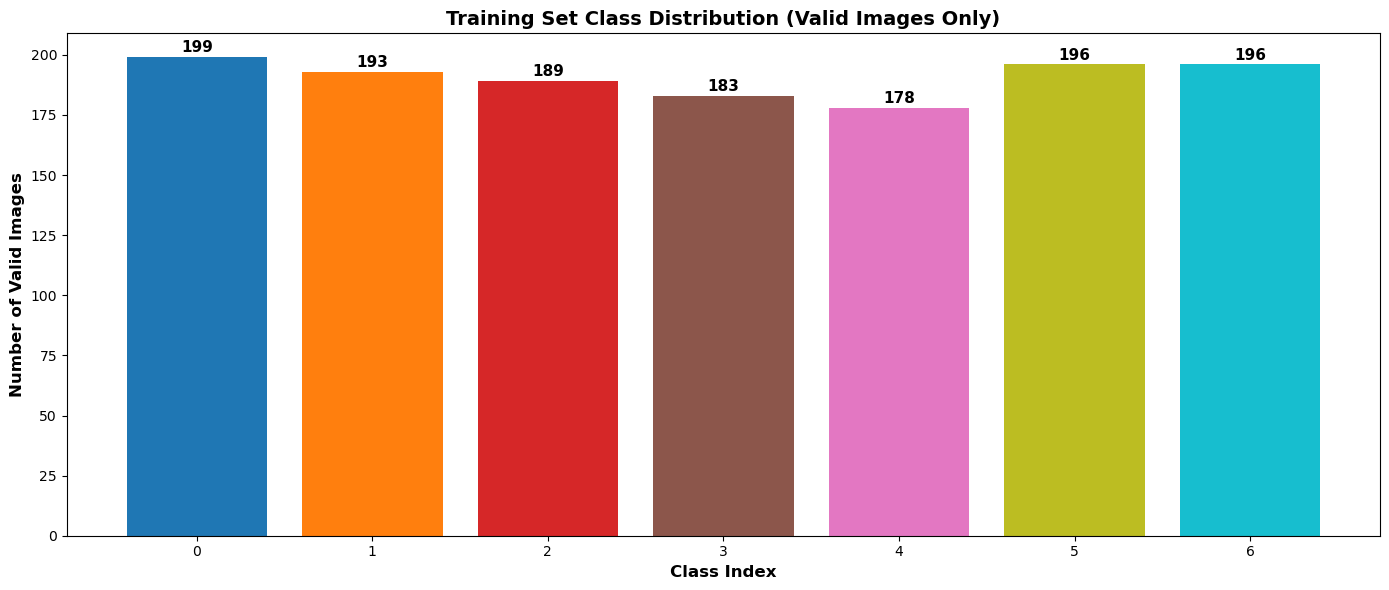

✓ Class distribution plot saved


In [13]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(14, 6))
class_names_display = [IDX_TO_CLASS[i] for i in sorted(class_counts.index)]
colors = plt.cm.tab10(np.linspace(0, 1, len(class_names_display)))
ax.bar(range(len(class_counts)), class_counts.values, color=colors)
ax.set_xlabel('Class Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Valid Images', fontsize=12, fontweight='bold')
ax.set_title('Training Set Class Distribution (Valid Images Only)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(class_counts)))
for i, (idx, count) in enumerate(class_counts.items()):
    ax.text(i, count + 2, str(count), ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(METADATA_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Class distribution plot saved")

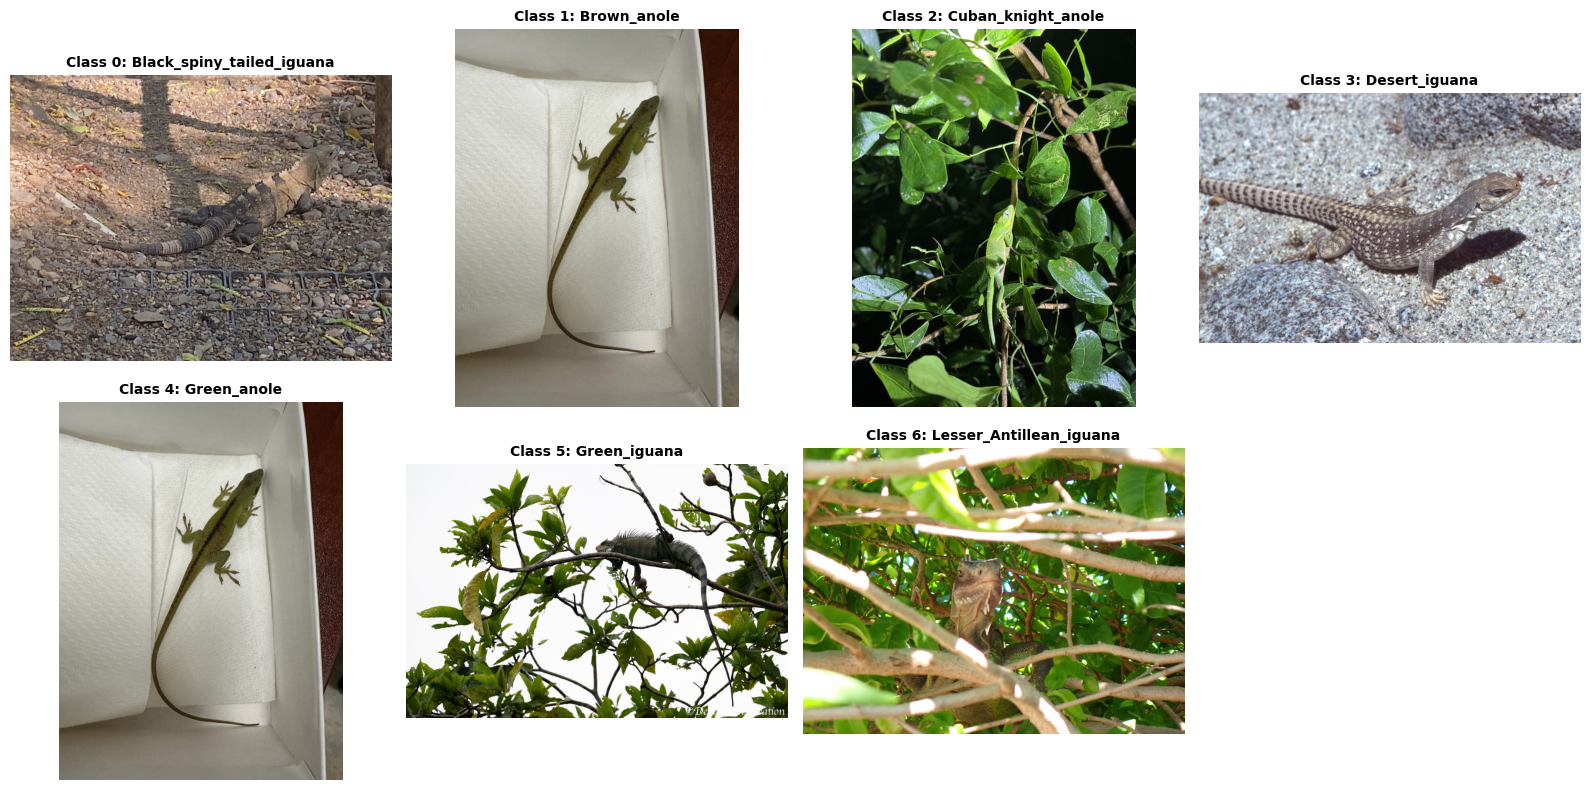

✓ Sample images plot saved


In [14]:
# Visualize sample images per class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for class_idx in range(len(CLASS_TO_IDX)):
    # Find first loadable image for this class
    class_samples = loadable_train_df[loadable_train_df['label'] == class_idx]
    if len(class_samples) > 0:
        sample_row = class_samples.iloc[0]
        img_path = resolve_image_path(sample_row['id'], class_idx)
        
        try:
            img = Image.open(str(img_path))
            axes[class_idx].imshow(img)
            axes[class_idx].set_title(f"Class {class_idx}: {IDX_TO_CLASS[class_idx]}", fontsize=10, fontweight='bold')
            axes[class_idx].axis('off')
        except Exception as e:
            axes[class_idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center', fontsize=9)
            axes[class_idx].axis('off')

# Hide extra subplot
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(METADATA_DIR / 'sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sample images plot saved")

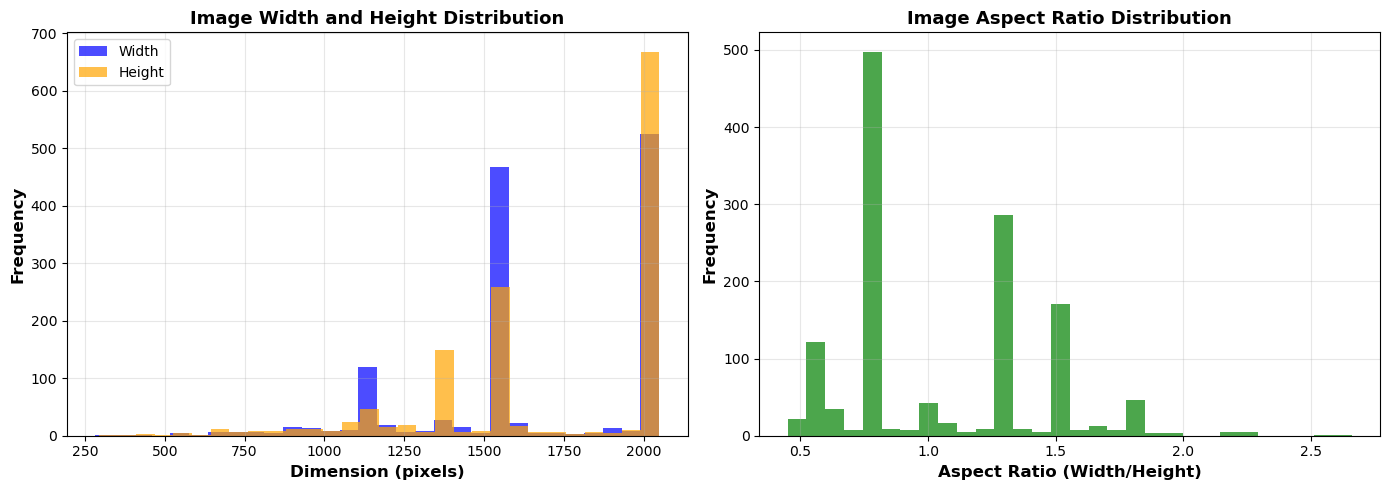

✓ Dimension distribution plot saved


In [15]:
# Image dimension distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(image_meta_df['width'], bins=30, alpha=0.7, label='Width', color='blue')
ax.hist(image_meta_df['height'], bins=30, alpha=0.7, label='Height', color='orange')
ax.set_xlabel('Dimension (pixels)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Image Width and Height Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
aspect_ratios = image_meta_df['width'] / image_meta_df['height']
ax.hist(aspect_ratios, bins=30, alpha=0.7, color='green')
ax.set_xlabel('Aspect Ratio (Width/Height)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Image Aspect Ratio Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(METADATA_DIR / 'image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Dimension distribution plot saved")

## Section 8: Validate Test Set

In [ ]:
# Validate test set
print("Validating test set...\n")

test_missing = []
test_corrupted = []
test_loadable = []
test_image_metadata = []

for test_id in test_df['id'].values:
    img_path = TEST_DIR / f"{test_id}.jpg"
    
    if not img_path.exists():
        test_missing.append(test_id)
        continue
    
    try:
        with Image.open(str(img_path)) as img:
            img_size = img.size
            img_format = img.format
            img_mode = img.mode
            test_loadable.append(test_id)
            test_image_metadata.append({
                'test_id': test_id,
                'width': img_size[0],
                'height': img_size[1],
                'format': img_format,
                'mode': img_mode
            })
    except Exception as e:
        test_corrupted.append((test_id, str(e)))

print(f"Total test records: {len(test_df)}")
print(f"✓ Loadable test images: {len(test_loadable)}")
print(f"✗ Missing test images: {len(test_missing)}")
print(f"✗ Corrupted test images: {len(test_corrupted)}")

if test_missing:
    print(f"\nMissing test images (first 5): {test_missing[:5]}")

if test_corrupted:
    print(f"\nCorrupted test images (first 5):")
    for test_id, error in test_corrupted[:5]:
        print(f"  {test_id}: {error}")

Validating test set...

Total test records: 326
✓ Loadable test images: 0
✗ Missing test images: 326
✗ Corrupted test images: 0

Missing test images (first 5): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
# Test set dimension statistics
test_meta_df = pd.DataFrame(test_image_metadata)

print("\nTest Set Image Statistics:")
print(f"  Total valid test images: {len(test_meta_df)}")
print(f"\n  Unique image sizes:")
test_size_dist = test_meta_df.groupby(['width', 'height']).size().sort_values(ascending=False)
print(test_size_dist.head(10))

print(f"\n  Dimension statistics:")
print(f"    Width  - min: {test_meta_df['width'].min()}, max: {test_meta_df['width'].max()}, mean: {test_meta_df['width'].mean():.1f}")
print(f"    Height - min: {test_meta_df['height'].min()}, max: {test_meta_df['height'].max()}, mean: {test_meta_df['height'].mean():.1f}")
print(f"    Aspect ratio - min: {(test_meta_df['width']/test_meta_df['height']).min():.2f}, max: {(test_meta_df['width']/test_meta_df['height']).max():.2f}")

## Section 9: Create Clean Datasets (No Data Deletion)

In [ ]:
# Create clean datasets with only valid/loadable files
# IMPORTANT: We do NOT delete data, we only filter to loadable files

clean_train_df = train_df[train_df['id'].isin(loadable_files)].copy().reset_index(drop=True)
clean_test_df = test_df[test_df['id'].isin(test_loadable)].copy().reset_index(drop=True)

print("Clean Datasets Created (No Data Deletion):")
print("="*70)
print(f"\nOriginal training records: {len(train_df)}")
print(f"Clean training records: {len(clean_train_df)}")
print(f"Records excluded (unreachable/corrupt): {len(train_df) - len(clean_train_df)}")
print(f"Retention rate: {100 * len(clean_train_df) / len(train_df):.2f}%")

print(f"\nOriginal test records: {len(test_df)}")
print(f"Clean test records: {len(clean_test_df)}")
print(f"Records excluded (unreachable/corrupt): {len(test_df) - len(clean_test_df)}")
print(f"Retention rate: {100 * len(clean_test_df) / len(test_df):.2f}%")

print(f"\nClean training set class distribution:")
for idx in sorted(clean_train_df['label'].unique()):
    count = (clean_train_df['label'] == idx).sum()
    print(f"  Class {idx}: {count} images")

## Section 10: Save Metadata for Downstream Notebooks

In [ ]:
# Save clean datasets
clean_train_df.to_csv(METADATA_DIR / 'clean_train.csv', index=False)
clean_test_df.to_csv(METADATA_DIR / 'clean_test.csv', index=False)

print("Saved datasets:")
print(f"  ✓ {METADATA_DIR / 'clean_train.csv'}")
print(f"  ✓ {METADATA_DIR / 'clean_test.csv'}")

In [ ]:
# Save class mappings as JSON
class_mappings = {
    'class_to_idx': CLASS_TO_IDX,
    'idx_to_class': {str(k): v for k, v in IDX_TO_CLASS.items()},
    'class_weights': {str(k): v for k, v in class_weight_dict.items()},
    'num_classes': len(CLASS_TO_IDX)
}

with open(METADATA_DIR / 'class_mappings.json', 'w') as f:
    json.dump(class_mappings, f, indent=2)

print(f"  ✓ {METADATA_DIR / 'class_mappings.json'}")

In [ ]:
# Save image metadata
image_meta_df.to_csv(METADATA_DIR / 'train_image_metadata.csv', index=False)
test_meta_df.to_csv(METADATA_DIR / 'test_image_metadata.csv', index=False)

print(f"  ✓ {METADATA_DIR / 'train_image_metadata.csv'}")
print(f"  ✓ {METADATA_DIR / 'test_image_metadata.csv'}")

In [ ]:
# Save configuration for downstream notebooks
config_dict = {
    'seed': SEED,
    'num_train_images': len(clean_train_df),
    'num_test_images': len(clean_test_df),
    'num_classes': len(CLASS_TO_IDX),
    'train_retention_rate': float(len(clean_train_df) / len(train_df)),
    'test_retention_rate': float(len(clean_test_df) / len(test_df)),
    'image_format': 'mixed (see metadata)',
    'recommended_image_size': 224,
    'recommended_batch_size': 32,
    'class_imbalance_ratio': float(class_counts.max() / class_counts.min())
}

with open(METADATA_DIR / 'eda_config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)

print(f"  ✓ {METADATA_DIR / 'eda_config.json'}")

## Section 11: Summary Report

In [ ]:
print("\n" + "="*80)
print("EDA SUMMARY - DATASET PREPARATION COMPLETE")
print("="*80)

print(f"\n✓ DATASET INTEGRITY")
print(f"  Training: {len(clean_train_df)}/{len(train_df)} images valid ({100*len(clean_train_df)/len(train_df):.2f}% retention)")
print(f"  Testing:  {len(clean_test_df)}/{len(test_df)} images valid ({100*len(clean_test_df)/len(test_df):.2f}% retention)")

print(f"\n✓ CLASS DISTRIBUTION")
print(f"  Classes: {len(CLASS_TO_IDX)}")
print(f"  Imbalance ratio: {class_counts.max() / class_counts.min():.3f}x")
print(f"  Minority class: {class_counts.min()} images")
print(f"  Majority class: {class_counts.max()} images")

print(f"\n✓ IMAGE CHARACTERISTICS")
print(f"  Width range: {image_meta_df['width'].min()}-{image_meta_df['width'].max()} px")
print(f"  Height range: {image_meta_df['height'].min()}-{image_meta_df['height'].max()} px")
print(f"  Most common size: {size_dist.index[0]}")
print(f"  Aspect ratio range: {(image_meta_df['width']/image_meta_df['height']).min():.2f}-{(image_meta_df['width']/image_meta_df['height']).max():.2f}")

print(f"\n✓ RECOMMENDATIONS FOR TRAINING")
print(f"  1. Target image size: 224×224 (standard for EfficientNet)")
print(f"  2. Use class weights to handle {class_counts.max() / class_counts.min():.1f}x imbalance")
print(f"  3. Apply data augmentation (flip, rotate, zoom) to boost effective dataset size")
print(f"  4. Stratified train/val split to preserve class distribution")

print(f"\n✓ METADATA SAVED")
print(f"  Location: {METADATA_DIR}")
print(f"  Files: clean_train.csv, clean_test.csv, class_mappings.json, eda_config.json,")
print(f"         train_image_metadata.csv, test_image_metadata.csv")

print(f"\n✓ READY FOR TRAINING NOTEBOOK")
print("="*80)